In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

In [2]:
combined_df = pd.read_csv('combined_df.csv')

In [3]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 48 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   customer_id                          9999 non-null   int64  
 1   target                               9999 non-null   int64  
 2   spend_cat_home                       9999 non-null   float64
 3   spend_cat_garden                     9999 non-null   float64
 4   spend_cat_sports                     9999 non-null   float64
 5   spend_cat_clothing                   9999 non-null   float64
 6   spend_cat_gifts                      9999 non-null   float64
 7   spend_cat_beauty                     9999 non-null   float64
 8   spend_cat_shoes                      9999 non-null   float64
 9   spend_cat_garden_accessories         9999 non-null   float64
 10  transactions_cat_home                9999 non-null   float64
 11  transactions_cat_garden       

In [4]:
combined_df['is_store_2'] = combined_df['closest_store'].apply(lambda x: 1 if x == 'STORE 2' else 0)

combined_df[['total_views', 'home_views', 'products_home', 'total_products']] = combined_df[['total_views', 'home_views', 'products_home', 'total_products']].fillna(0)

In [14]:
feature_variables = ['spend_cat_home',
                     'calculated_total_spend',
                     'transactions_cat_home',
                     #'days_since_last_home_purchase',
                     'loyalty_customer',
                     'distance_from_store',
                     'jl_tenure',
                     'wtr_spend',
                     'wtr_tenure',
                     'home_views',
                     'total_views',
                    'is_store_2']
                     #'products_home',
                     #'total_products']

In [15]:
X = combined_df[feature_variables]
y = combined_df['target']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [23]:
rf = RandomForestClassifier(n_estimators=400,max_depth=10,class_weight='balanced')

# Train the model
rf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1284
           1       0.69      0.80      0.74       716

    accuracy                           0.80      2000
   macro avg       0.78      0.80      0.79      2000
weighted avg       0.81      0.80      0.80      2000



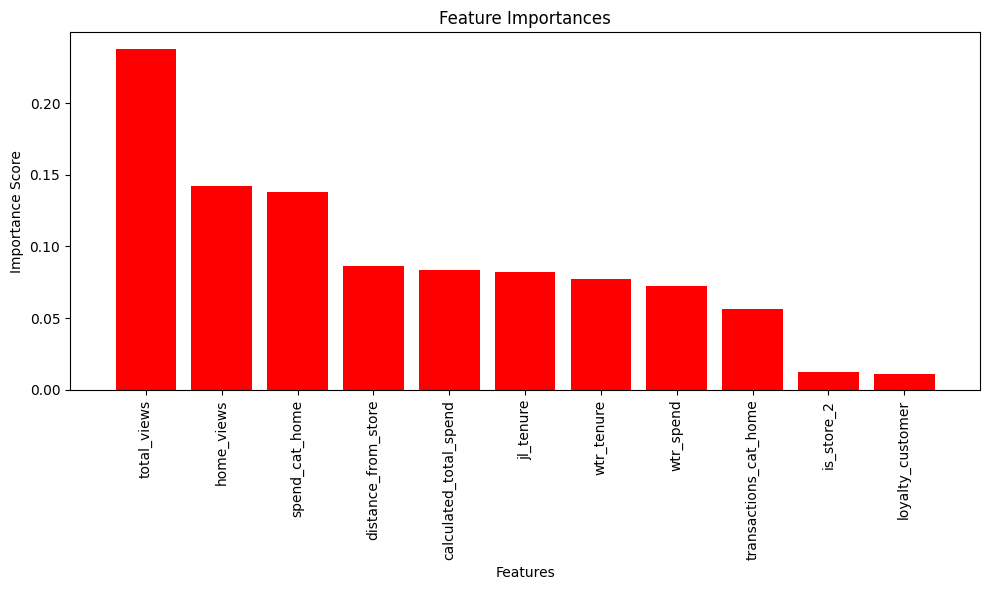

In [8]:
# Extract and sort feature importances
feature_importances = rf.feature_importances_
indices = np.argsort(feature_importances)[::-1]  # Indices of sorted feature importances

# Now plot the feature importances
plt.figure(figsize=(10, 6))
plt.title('Feature Importances')
plt.bar(range(X_train.shape[1]), feature_importances[indices], color="r", align="center")

# Attempt to use column names if available
try:
    feature_names = X_train.columns
    plt.xticks(range(X_train.shape[1]), feature_names[indices], rotation=90)
except AttributeError:
    plt.xticks(range(X_train.shape[1]), [f"Feature {i}" for i in indices], rotation=90)

plt.xlim([-1, X_train.shape[1]])
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

10
[0.7890798899449725]
110
[0.7890798899449725, 0.8042812906453227]
210
[0.7890798899449725, 0.8042812906453227, 0.8054814407203601]
310
[0.7890798899449725, 0.8042812906453227, 0.8054814407203601, 0.8068816408204104]
410
[0.7890798899449725, 0.8042812906453227, 0.8054814407203601, 0.8068816408204104, 0.8070817908954477]
510
[0.7890798899449725, 0.8042812906453227, 0.8054814407203601, 0.8068816408204104, 0.8070817908954477, 0.8071817408704351]
610
[0.7890798899449725, 0.8042812906453227, 0.8054814407203601, 0.8068816408204104, 0.8070817908954477, 0.8071817408704351, 0.8064815407703853]


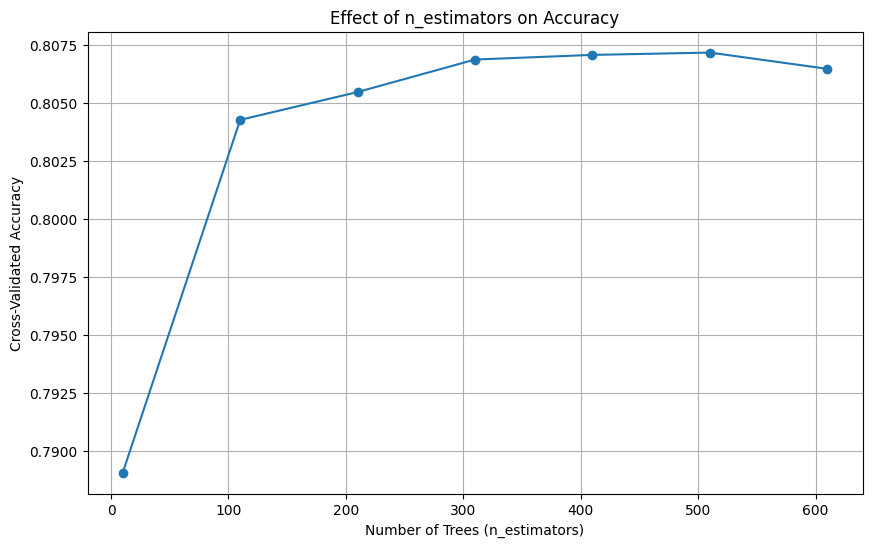

In [28]:
from sklearn.model_selection import cross_val_score
# Define a range of n_estimators
n_estimators_range = range(10, 611, 100)

# Store the mean accuracy for each n_estimators
mean_accuracies = []

for n_estimators in n_estimators_range:
    print(n_estimators)
    rf = RandomForestClassifier(n_estimators=n_estimators, class_weight='balanced', random_state=42)
    # Perform cross-validation
    scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')  # 5-fold cross-validation
    mean_accuracies.append(scores.mean())
    print(mean_accuracies)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, mean_accuracies, marker='o', linestyle='-')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Effect of n_estimators on Accuracy')
plt.grid()
plt.show()

3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


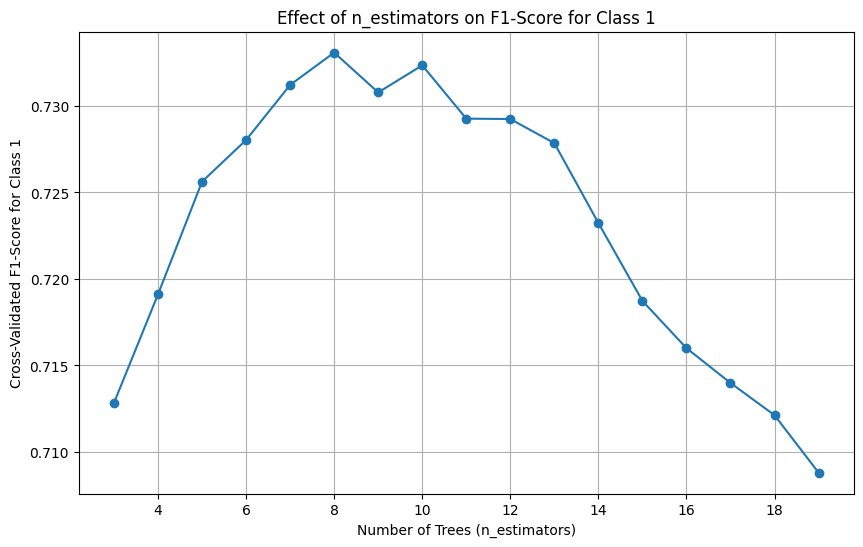

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, make_scorer
import matplotlib.pyplot as plt

# Define a custom scorer for F1-score of class 1
f1_class_1_scorer = make_scorer(f1_score, pos_label=1)

# Define a range of n_estimators
n_estimators_range = range(10, 612, 100)
max_depths = np.arange(3, 20)

# Store the mean F1-scores for class 1
mean_f1_scores = []

for max_depth in max_depths:
    print(max_depth)
    rf = RandomForestClassifier(n_estimators=100, max_depth=max_depth, class_weight='balanced', random_state=42)
    # Perform cross-validation
    scores = cross_val_score(rf, X, y, cv=5, scoring=f1_class_1_scorer)  # 5-fold cross-validation
    mean_f1_scores.append(scores.mean())

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(max_depths, mean_f1_scores, marker='o', linestyle='-')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Cross-Validated F1-Score for Class 1')
plt.title('Effect of n_estimators on F1-Score for Class 1')
plt.grid()
plt.show()